****Student Performance Indicator****

**##Problem statement**   
This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

**##Data Collection**   
Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977   
The data consists of 8 column and 1000 rows.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.tail()
df.shape

(1000, 8)

**2.2 Dataset information**
gender : sex of students -> (Male/female)
race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
lunch : having lunch before test (standard or free/reduced)
test preparation course : complete or not complete before test
math score
reading score
writing score

**DATA Checks**

In [12]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

NO missing values

In [15]:
df.duplicated().sum()

0

No duplicate values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [17]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [18]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Exploring the data**

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
print("Categories in gender: " , end="")
print(df['gender'].unique())

Categories in gender: ['female' 'male']


In [22]:
print("Categories in race ethinicity: " , end="")
print(df['race/ethnicity'].unique())

Categories in race ethinicity: ['group B' 'group C' 'group A' 'group D' 'group E']


In [27]:
print("Categories in parental level of education:", end="\n")
print(df['parental level of education'].unique())

Categories in parental level of education:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [29]:
print("Categories in Lunch:", end="")
print(df['lunch'].unique())

Categories in Lunch:['standard' 'free/reduced']


In [30]:
print("Categories in test preparation course:", end="")
print(df['test preparation course'].unique())

Categories in test preparation course:['none' 'completed']


In [4]:
# defining numerical and categorical columns
numerical_features =[feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features =[feature for feature in df.columns if df[feature].dtype == 'O']

print ("Numerical features: {} and are : {}".format(len(numerical_features), numerical_features))
print ("Categorical features: {} and are : {}".format(len(categorical_features), categorical_features))

Numerical features: 3 and are : ['math score', 'reading score', 'writing score']
Categorical features: 5 and are : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [5]:
df['total score']= df['math score']+df['reading score']+df['writing score']
df['average score']= df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [6]:
reading_fullmark =df[df['reading score']==100]['average score'].count()
writing_fullmark=df[df['writing score']==100]['average score'].count()
math_fullmark=df[df['math score']==100]['average score'].count()

In [7]:
print (f'Number of student with full marks in reading: {reading_fullmark}')
print (f'Number of student with full marks in writing: {writing_fullmark}')
print (f'Number of student with full marks in math: {math_fullmark}')


Number of student with full marks in reading: 17
Number of student with full marks in writing: 14
Number of student with full marks in math: 7


In [8]:
reading_less20 =df[df['reading score']<=20]['average score'].count()
writing_less20=df[df['writing score']<=20]['average score'].count()
math_less20=df[df['math score']<=20]['average score'].count()



print (f'Number of student with low scores in reading: {reading_less20}')
print (f'Number of student with low scores in writing: {writing_less20}')
print (f'Number of student with low scores in math: {math_less20}')

Number of student with low scores in reading: 1
Number of student with low scores in writing: 3
Number of student with low scores in math: 4


In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


**Exploring the data (Visulaization)**

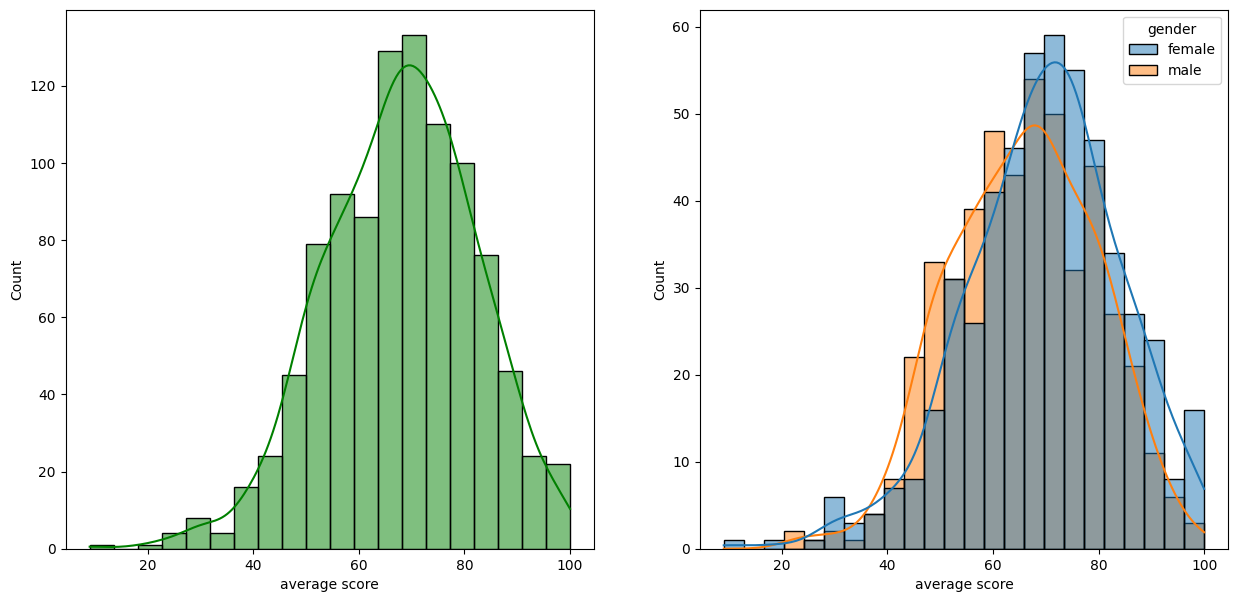

In [10]:
fig ,axis=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average score',bins=20,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average score',kde=True,hue='gender')
plt.show()

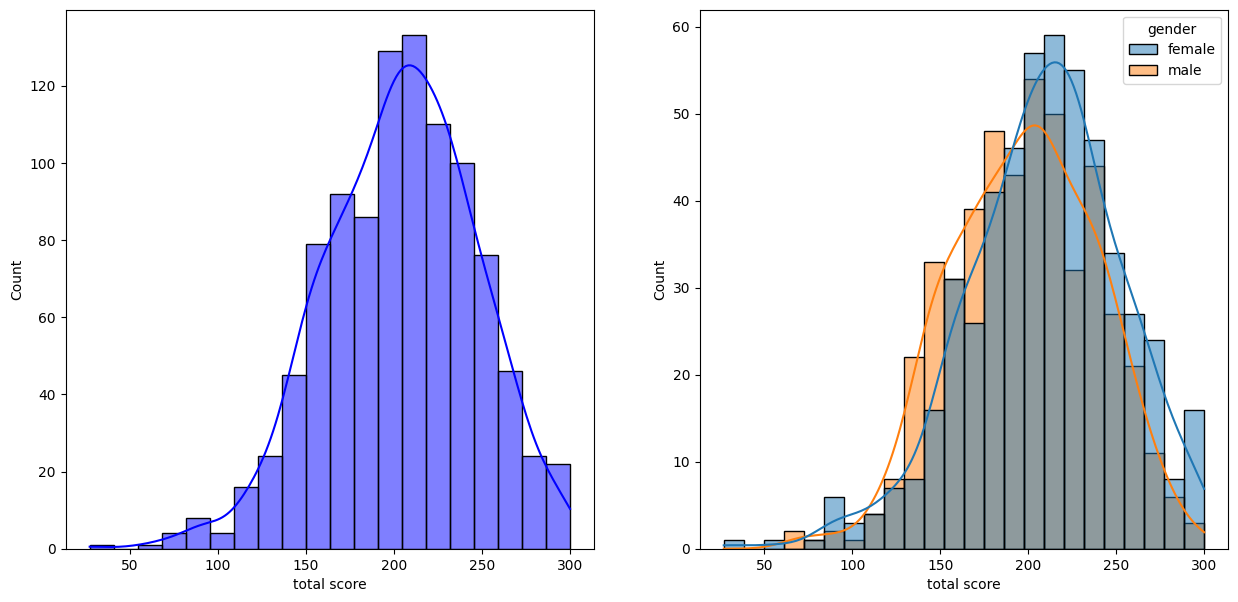

In [11]:
fig,axis=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,  x='total score',bins=20,kde=True,color='b')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True, hue='gender')
plt.show()

**Insights**
female perform well than male students

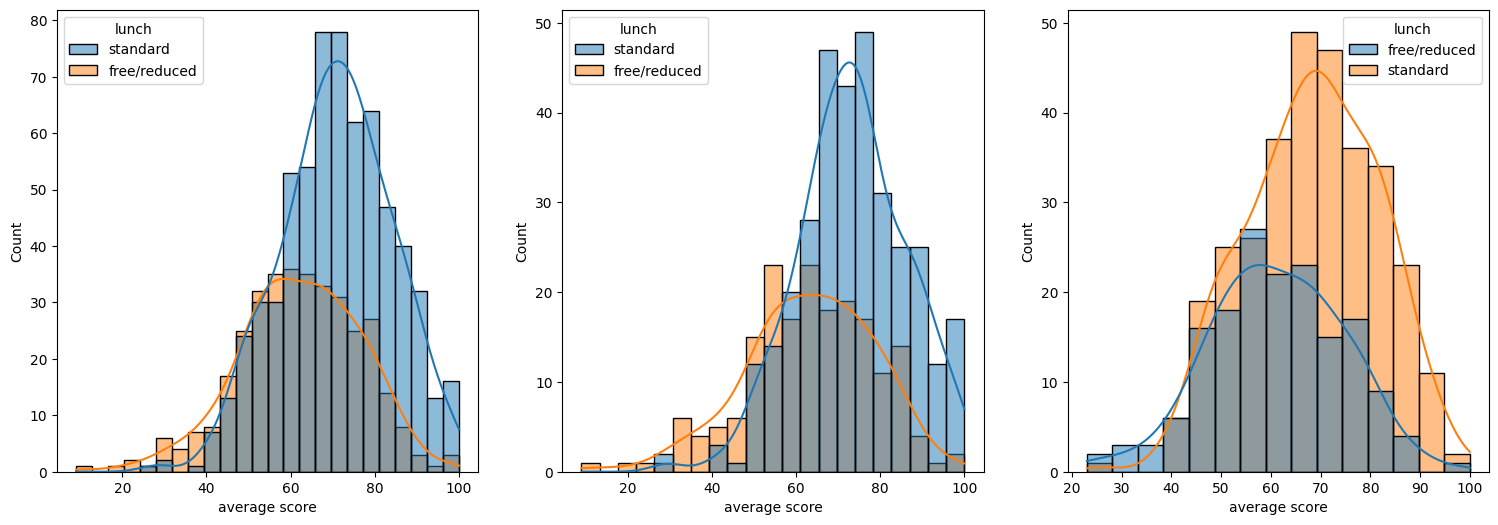

In [12]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average score', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='lunch')
plt.show()

**Insights**
Standard lunch helps perform well in exams.
Standard lunch helps perform well in exams be it a male or a female.

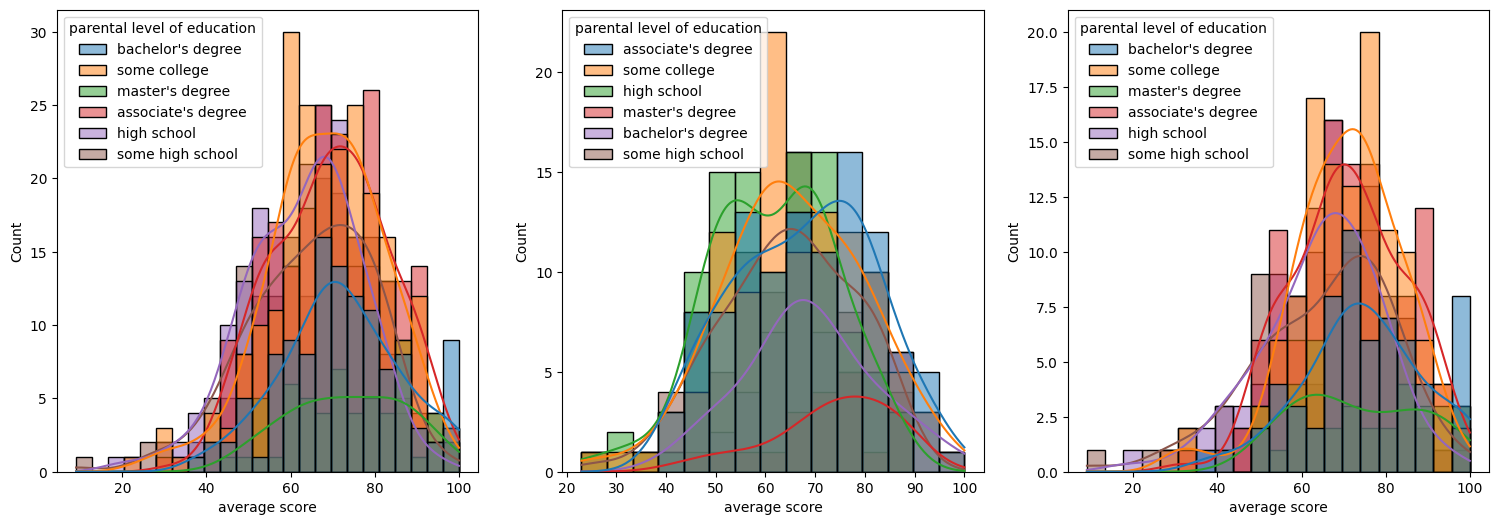

In [13]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax=sns.histplot(data=df, x='average score', kde=True, hue='parental level of education')
plt.subplot(142)
ax=sns.histplot(data=df[df.gender=='male'], x='average score', kde=True, hue='parental level of education')
plt.subplot(143)
ax=sns.histplot(data=df[df.gender=='female'], x='average score', kde=True, hue='parental level of education')
plt.show()

Insight:
1. In general parent's education don't help student perform well in exam.
2. 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
3. 3rd plot we can see there is no effect of parent's education on female students.

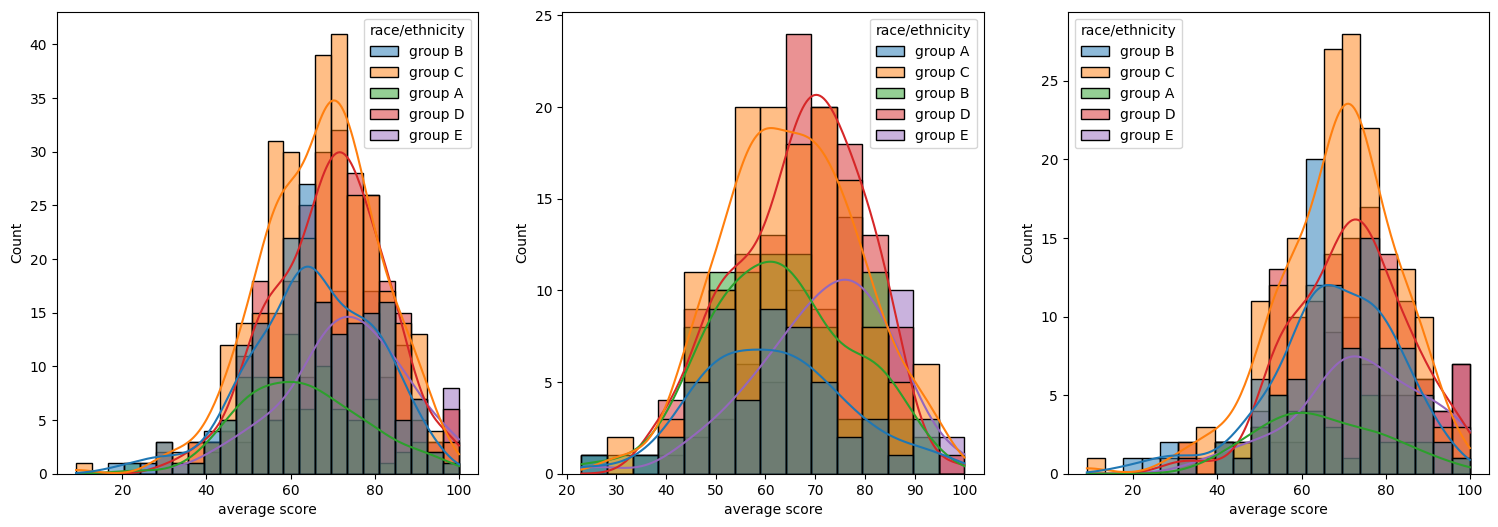

In [16]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average score',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='race/ethnicity')
plt.show()

Insights:
1. Students of group A and group B tends to perform poorly in exam.
2. Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

4.2 Maximumum score of students in all three subjects

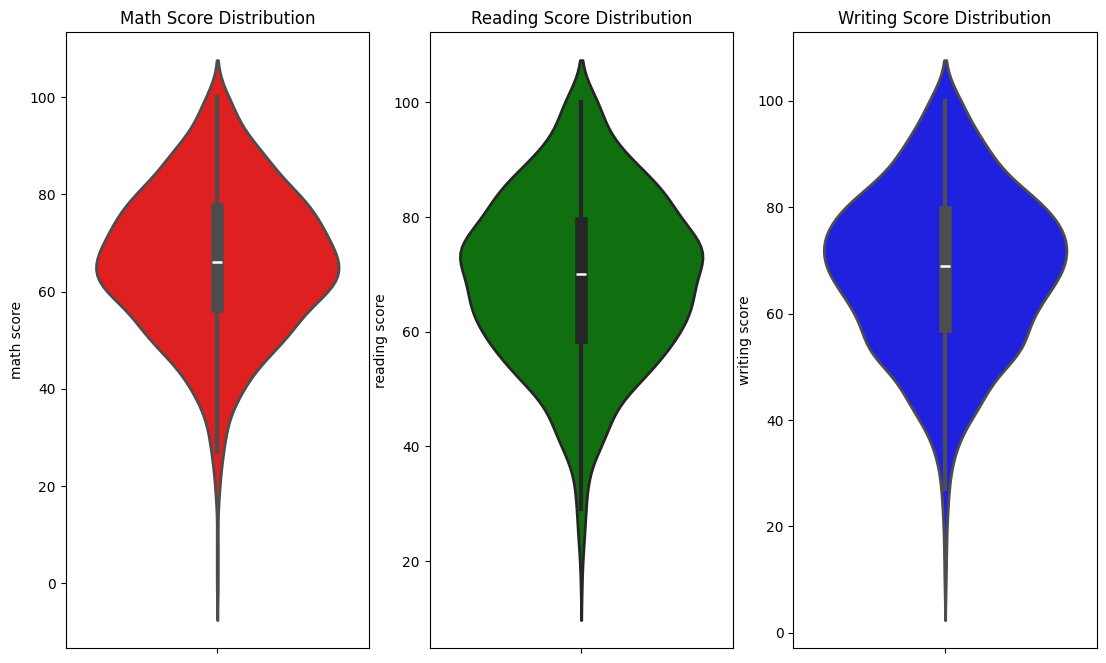

In [17]:
plt.figure(figsize=(18,8))
plt.subplot(141)
plt.title('Math Score Distribution')
sns.violinplot(y='math score',data=df,color='red', linewidth=2)
plt.subplot(142)
plt.title('Reading Score Distribution') 
sns.violinplot(y='reading score',data=df,color='green', linewidth=2)
plt.subplot(143)
plt.title('Writing Score Distribution')
sns.violinplot(y='writing score',data=df,color='blue', linewidth=2)
plt.show()

Insight:   Most of the student lie in 60-80 marks range in maths but in reading and writng 50-80.


*Multivariate analysis using pieplot*

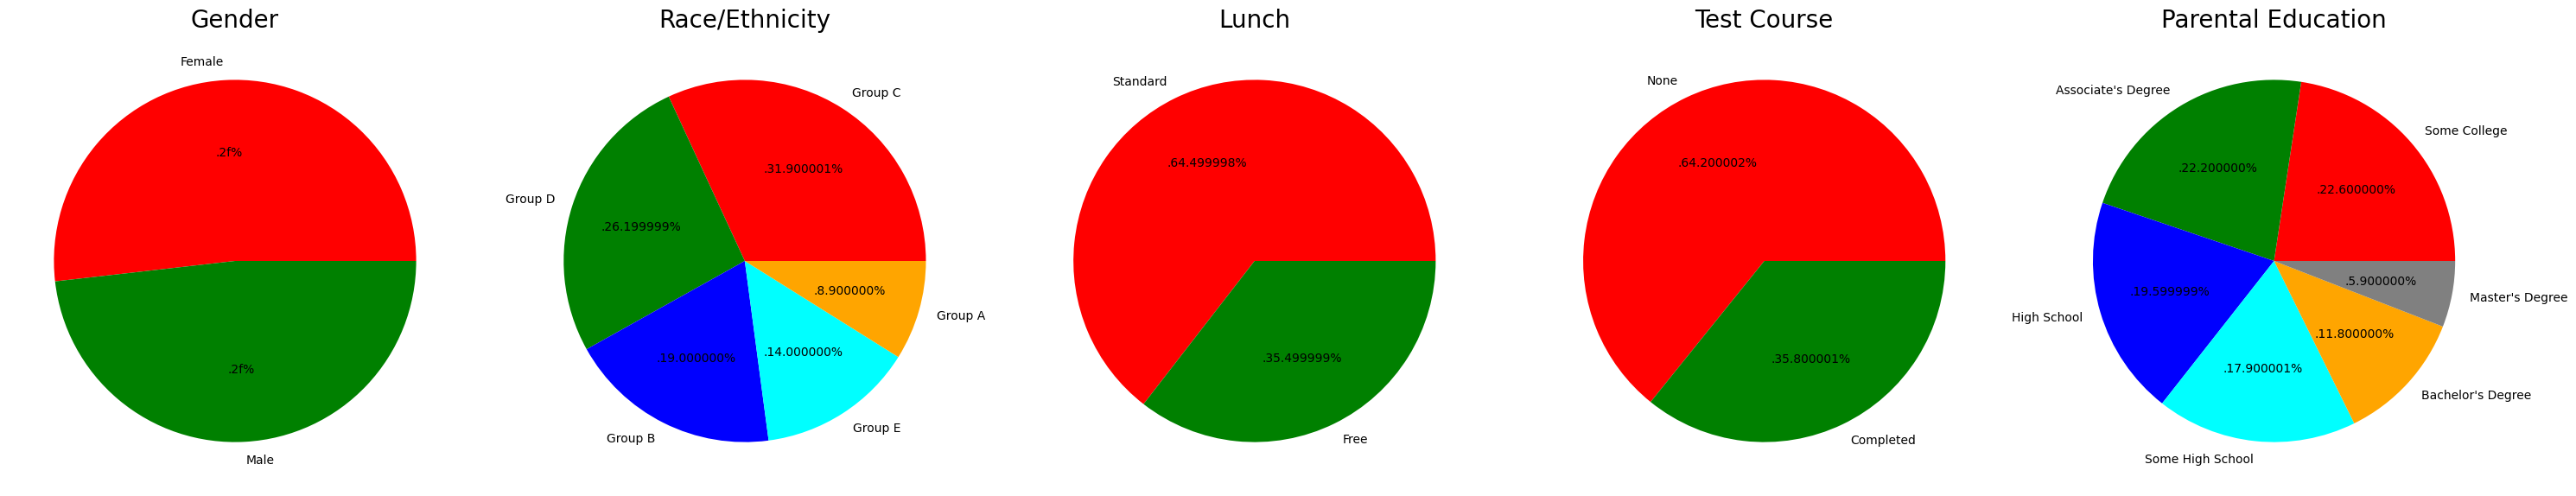

In [18]:
plt.rcParams['figure.figsize'] = (30,12)
plt.subplot(151)
size =df['gender'].value_counts()
labels= 'Female','Male'
color=['red','green']


plt.pie(size,colors=color,labels=labels,autopct='.2f%%')
plt.title('Gender', fontsize=20 )
plt.axis('off')

plt.subplot(152)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(153)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(154)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(155)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

Insights
1. Number of Male and Female students is almost equal
2. Number students are greatest in Group C
3. Number of students who have standard lunch are greater
4. Number of students who have not enrolled in any test preparation course is greater
5. Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

**Feature Wise Visualization**

1. GENDER COLUMN


Univariate analysis


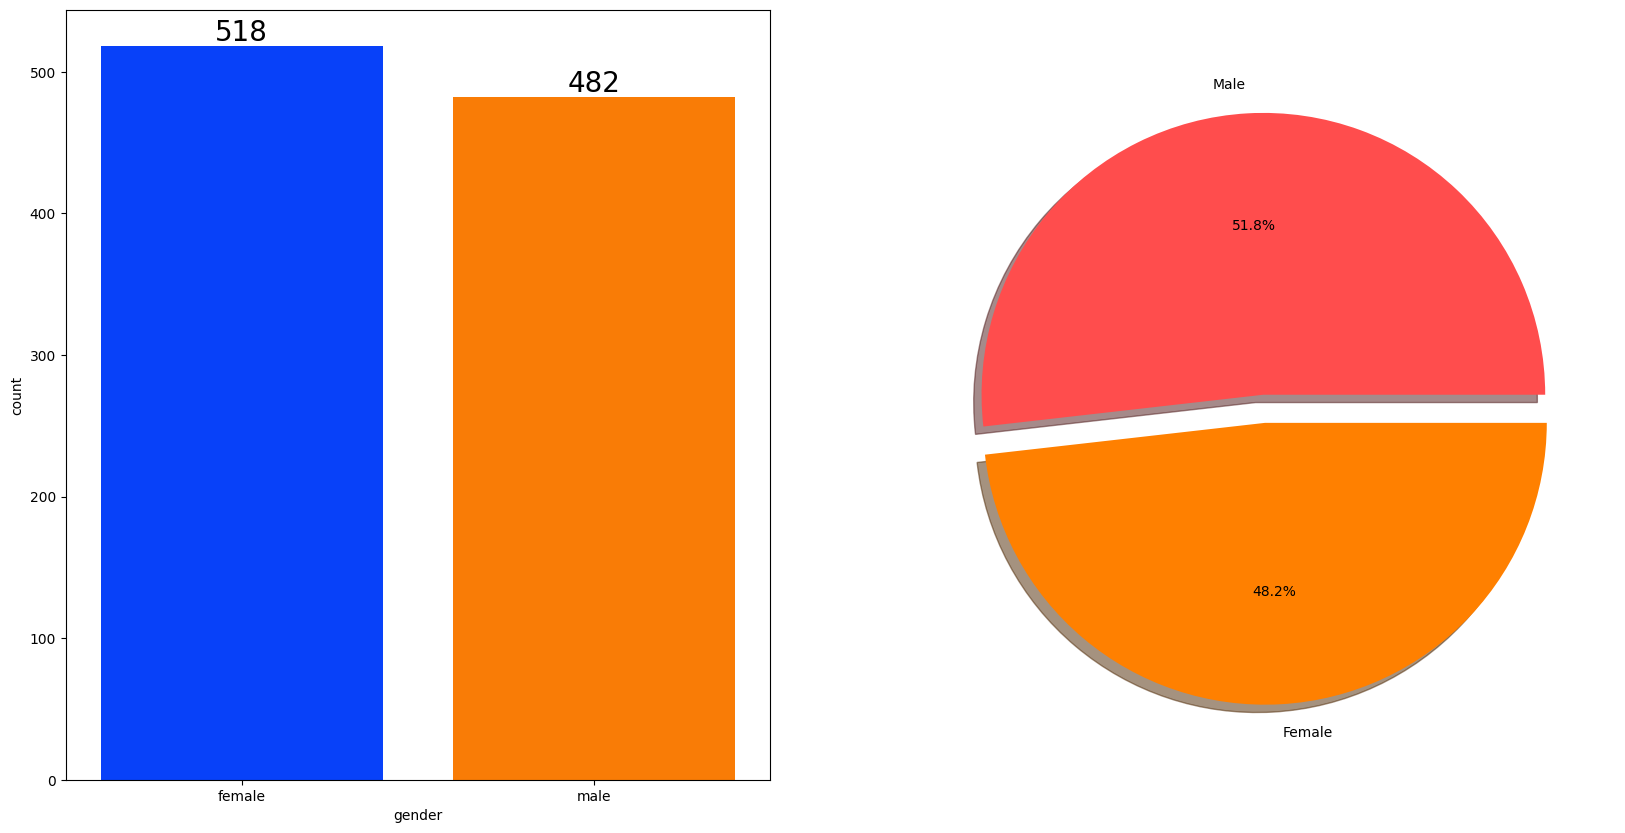

In [28]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
   ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True, colors=['#ff4d4d','#ff8000'])
plt.show()

Insights:   
Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

Bivariate analysis


In [25]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


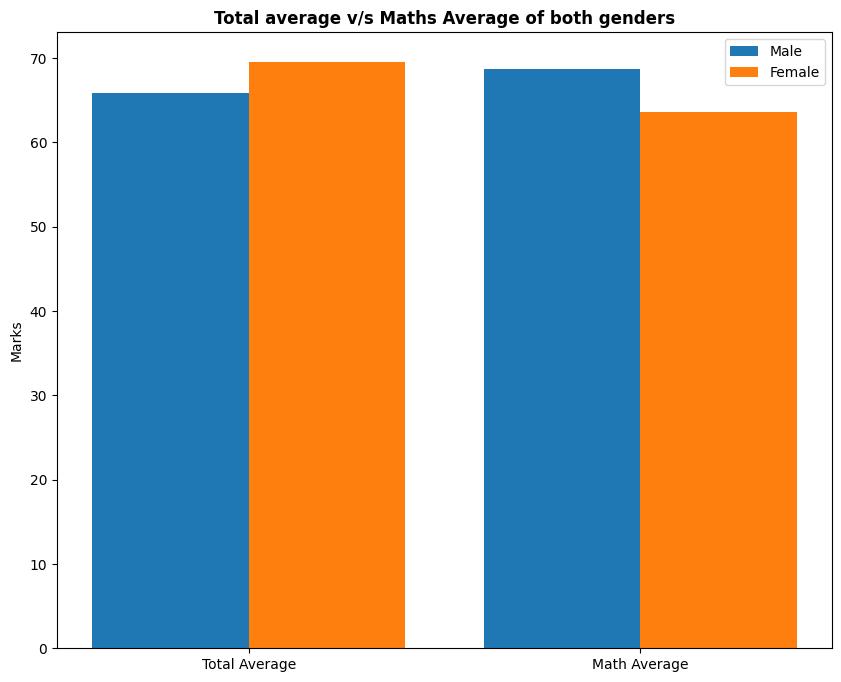

In [27]:
plt.figure(figsize=(10,8))
X=['Total Average', 'Math Average']

female_score=[gender_group['average score'][0], gender_group['math score'][0]]
male_score=[gender_group['average score'][1], gender_group['math score'][1]]
X_axis=np.arange(len(X))
plt.bar(X_axis-0.2, male_score,0.4,label='Male')
plt.bar(X_axis+0.2, female_score,0.4,label='Female')
plt.xticks(X_axis,X)
plt.ylabel('Marks')
plt.title("Total average v/s Maths Average of both genders", fontweight='bold')
plt.legend()
plt.show()

Insight:   
Total average is better in females   
males have higher scores in maths

** RACE/EHNICITY COLUMN**

Univariate Analysis


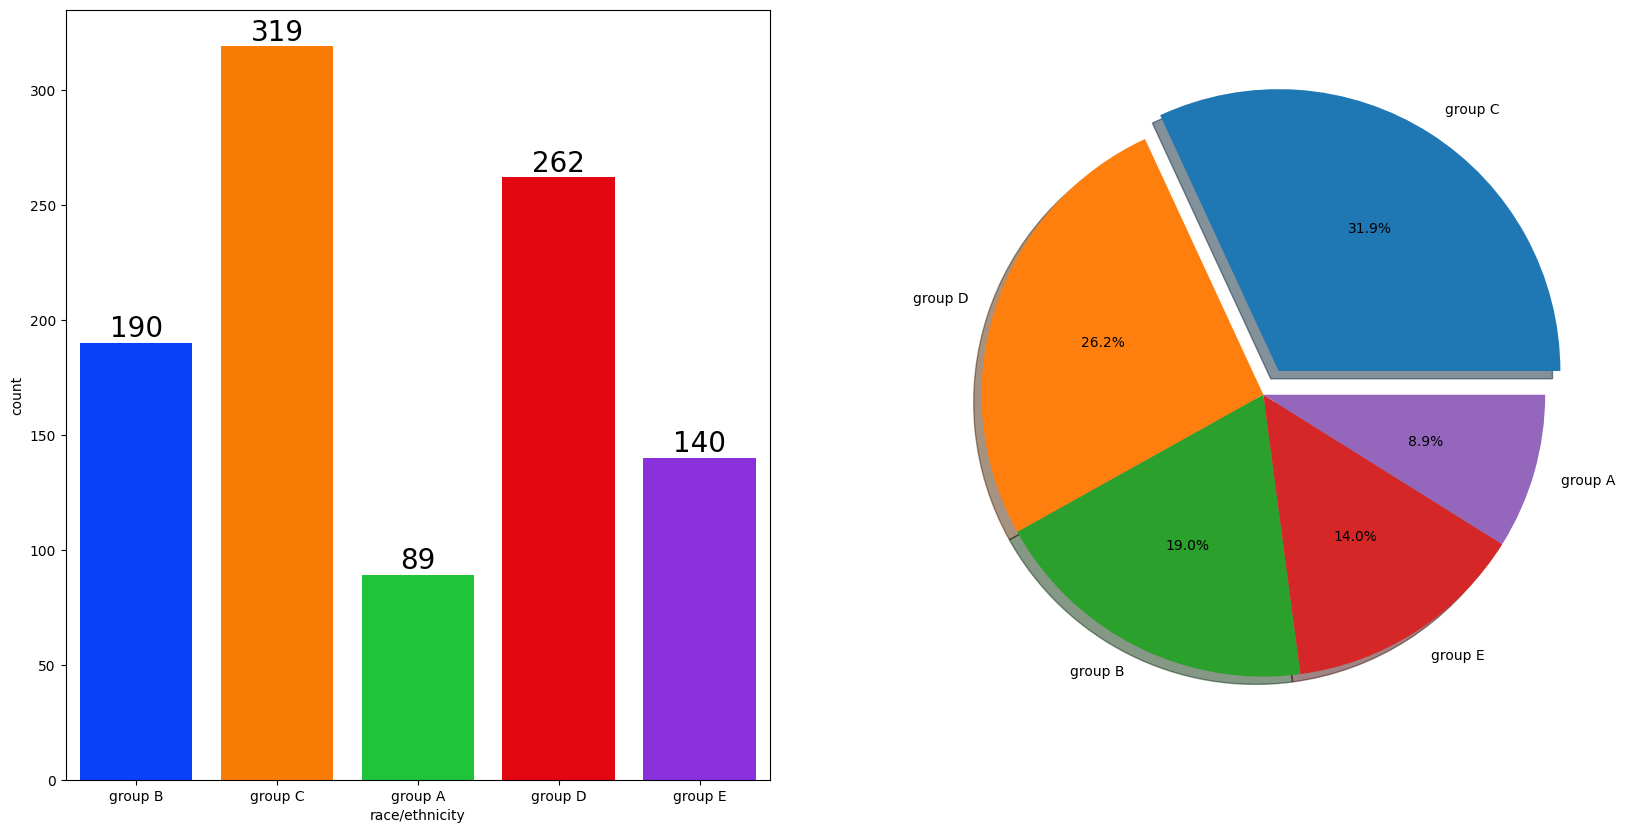

In [32]:
f,ax=plt.subplots(1,2, figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%', shadow='True')
plt.show()

Insight:  
most stuent belong to group C / group D   
lowest no of student belong to group A

BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

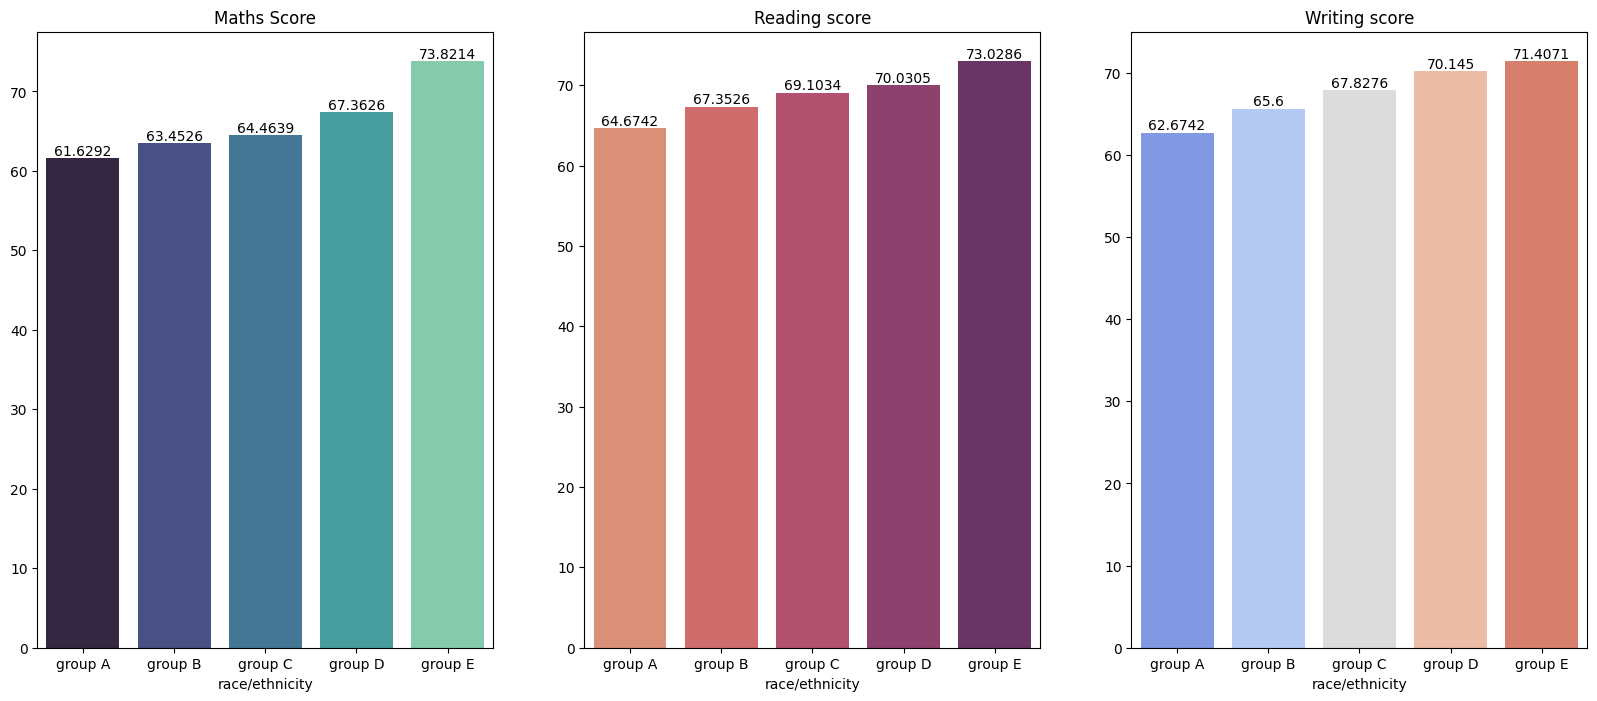

In [33]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3, figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index, y=Group_data2['math score'].mean().values,palette='mako',ax=ax[0])
ax[0].set_title("Maths Score")

for container in ax[0].containers:
    ax[0].bar_label(container)
sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score')

for container in ax[1].containers:
    ax[1].bar_label(container)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score')

for container in ax[2].containers:
    ax[2].bar_label(container)  

Insights:   
Group E students have scored the highest marks.  
Group A students have scored the lowest marks.   
Students from a lower Socioeconomic status have a lower avg in all course subjects

**PARENTAL LEVEL OF EDUCATION COLUMN**

Univariate analysis

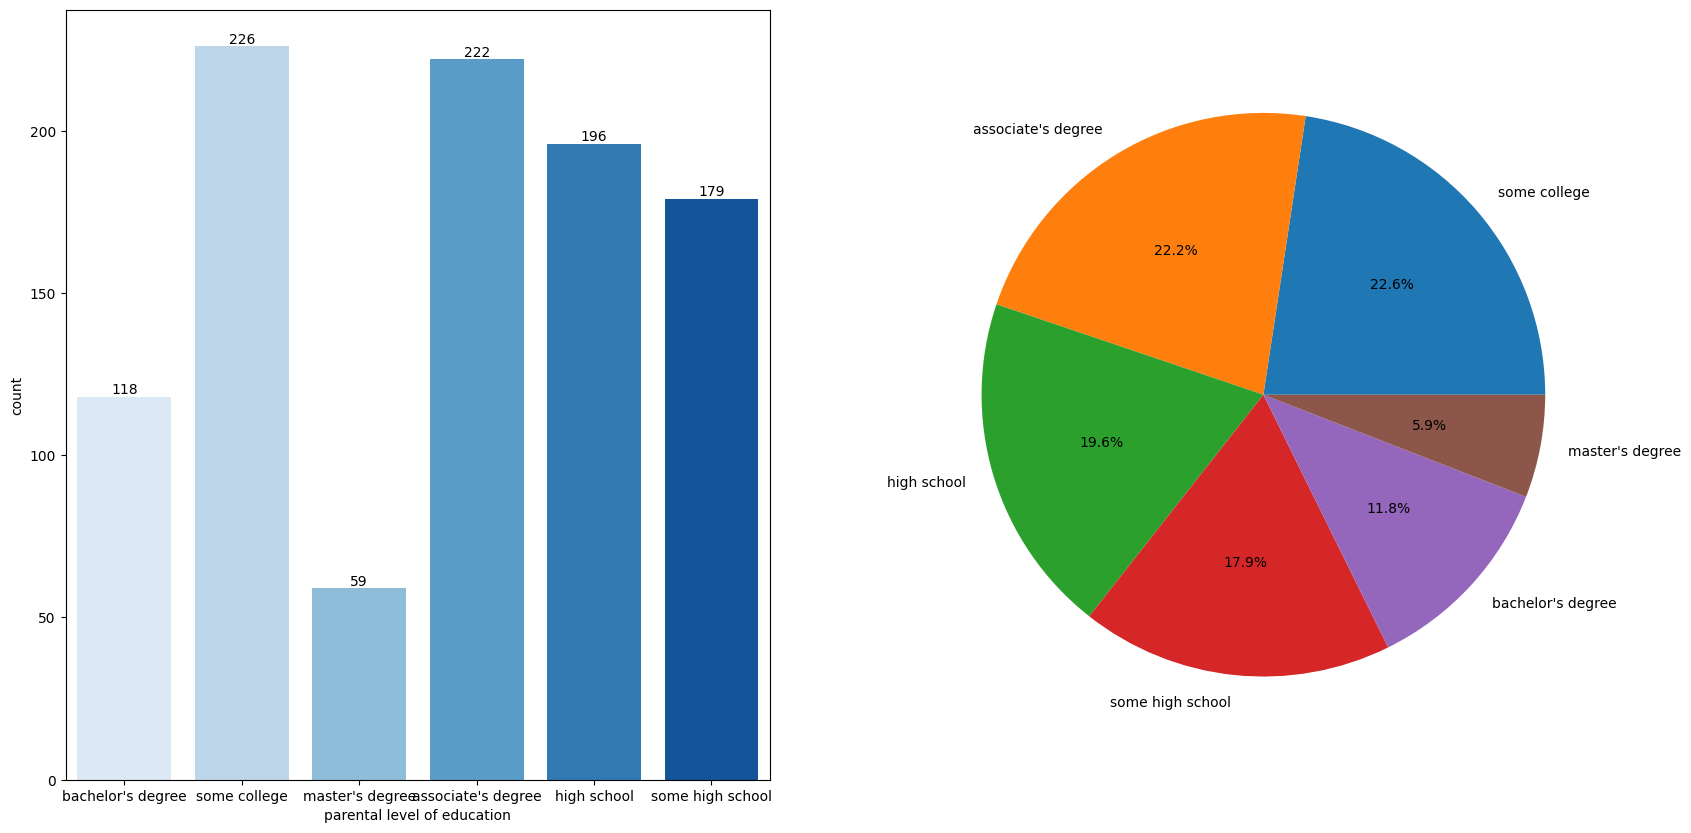

In [39]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(x='parental level of education',data=df,palette='Blues',ax=ax[0], saturation=0.9)

for container in ax[0].containers:
    ax[0].bar_label(container)
plt.pie(x=df['parental level of education'].value_counts(),labels=df['parental level of education'].value_counts().index, autopct="%1.1f%%")
plt.show()


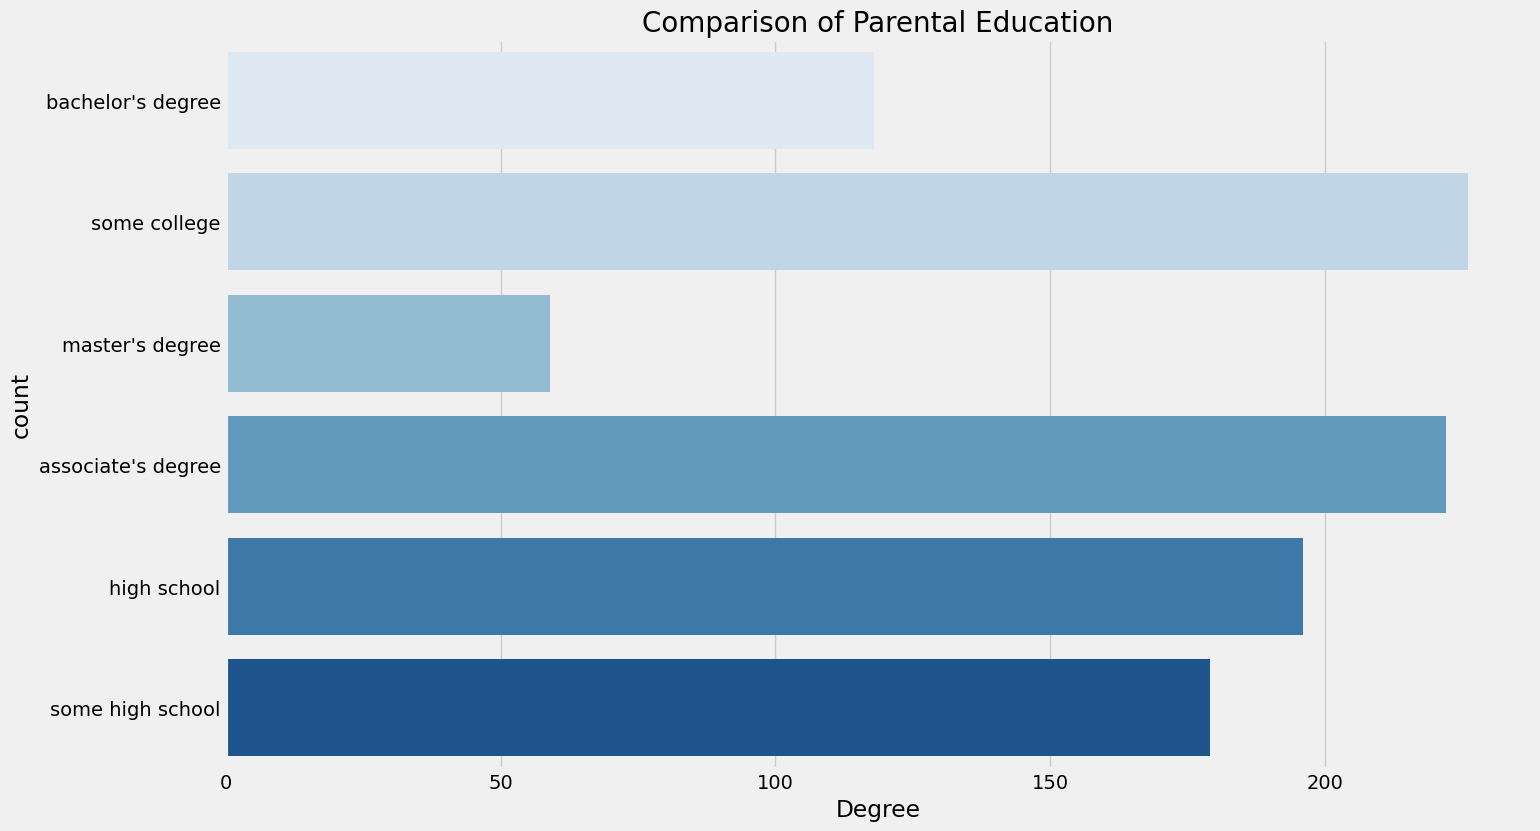

In [40]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

Insight:  
Largest number of parents are from some college 


BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )


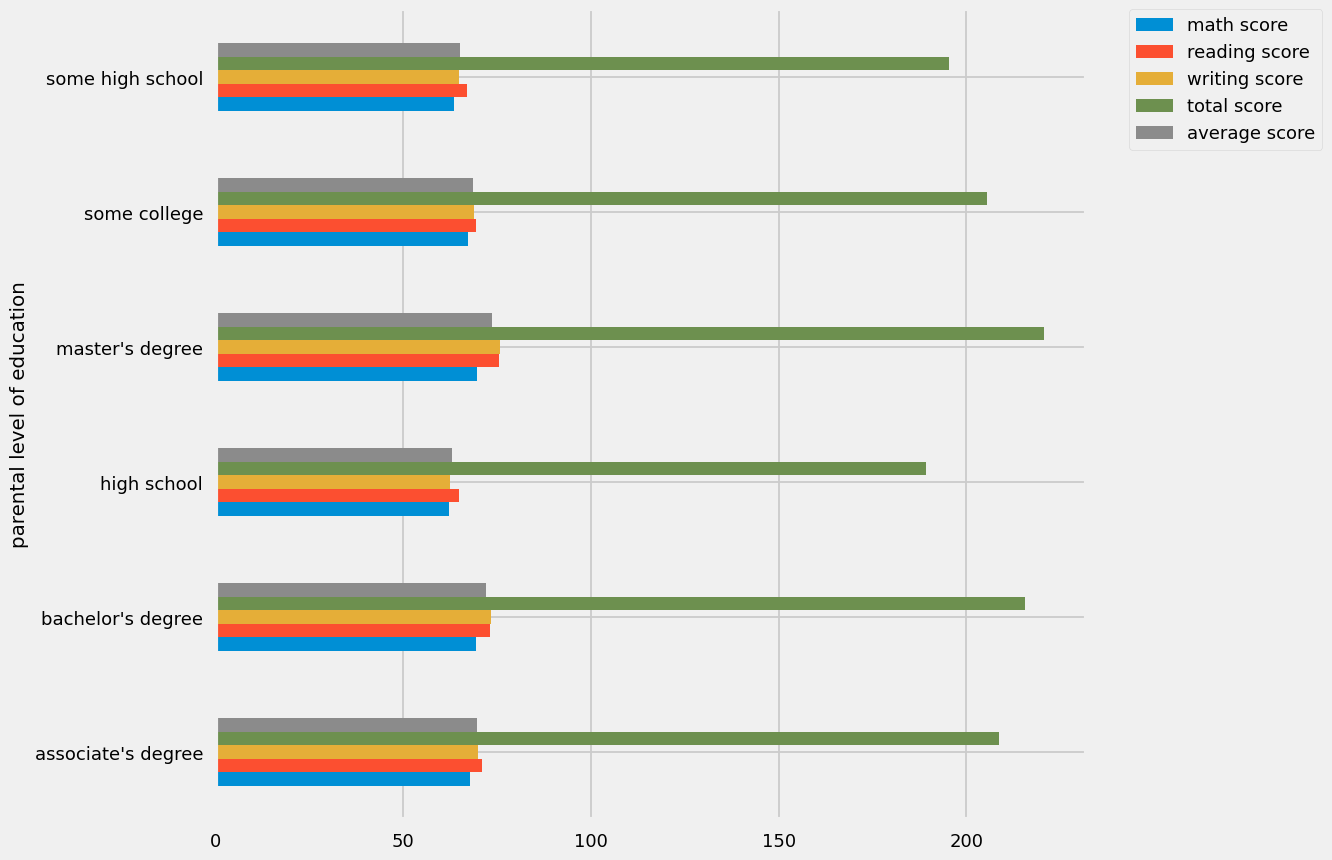

In [56]:
df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


**LUNCH COLUMN**

UNIVARIATE ANALYSIS


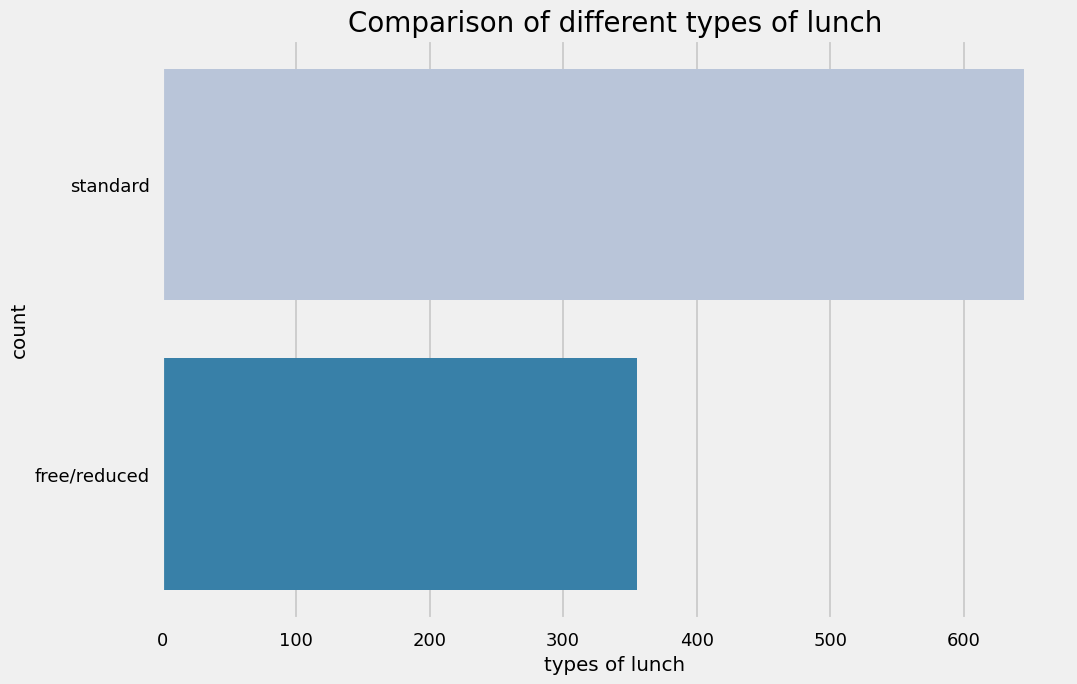

In [52]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

Insights:   
Students being served Standard lunch was more than free lunch


BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

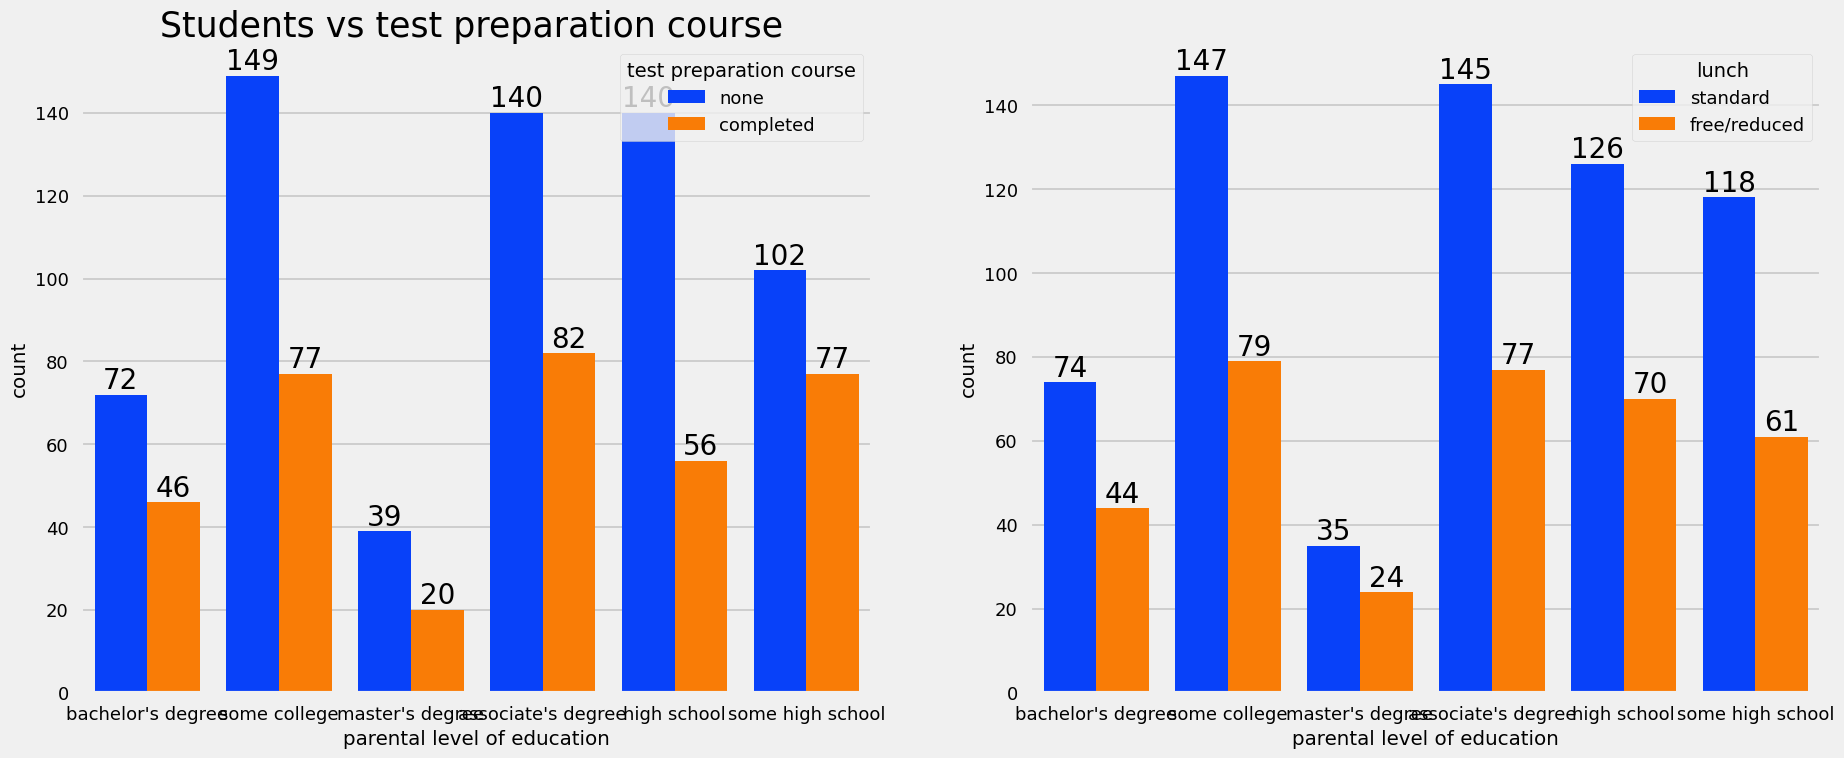

In [53]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

Insights:  
Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

**TEST PREPARATION COURSE COLUMN**

BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

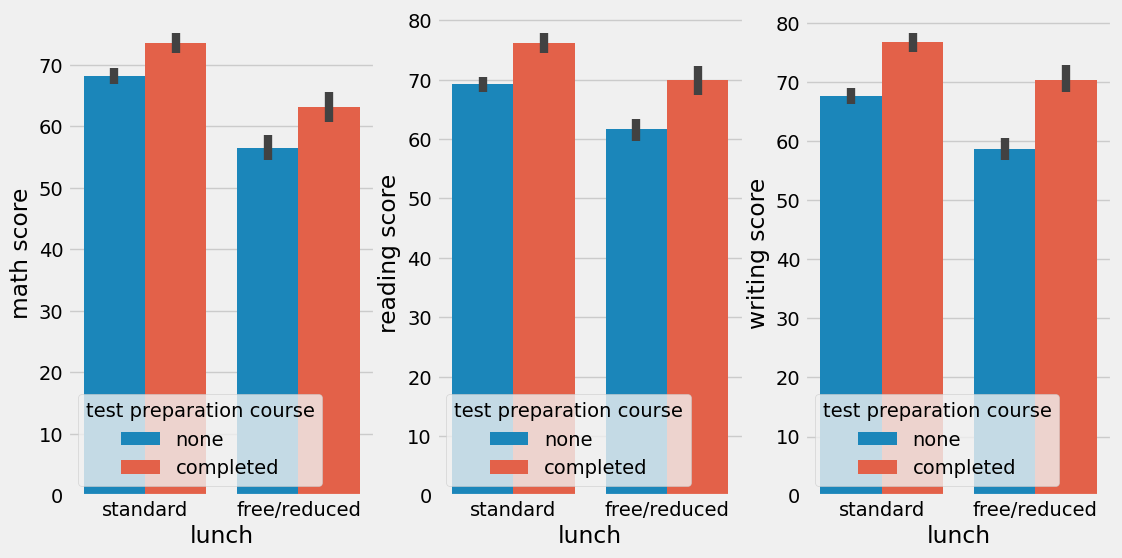

In [51]:
plt.subplots(1,4,figsize=(12,6))
plt.subplot(131)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(132)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(133)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

Insights:   
Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

**CHECKING OUTLIERS**

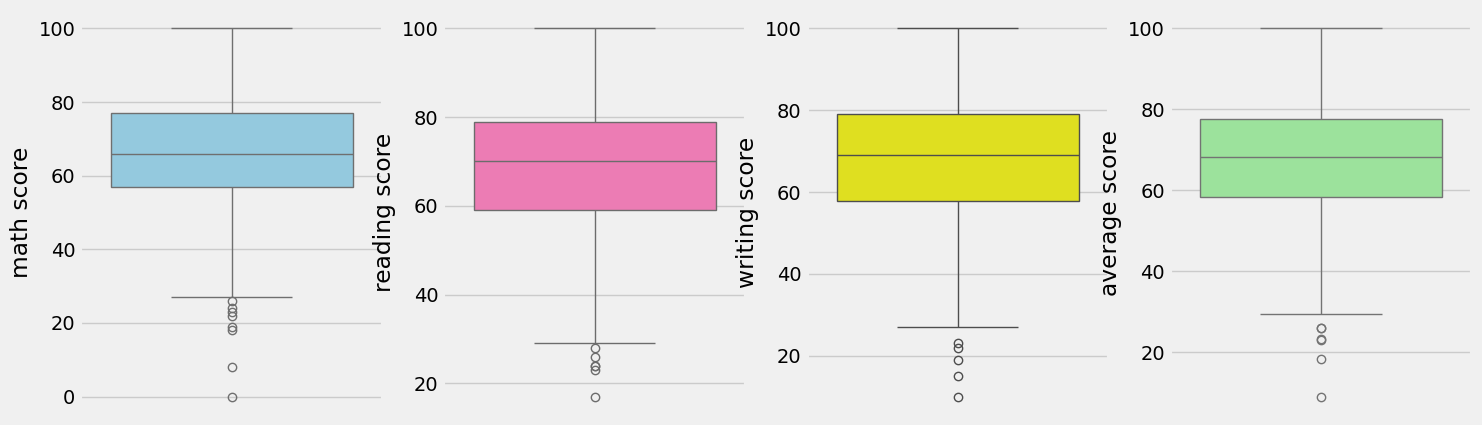

In [45]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average score'],color='lightgreen')
plt.show()

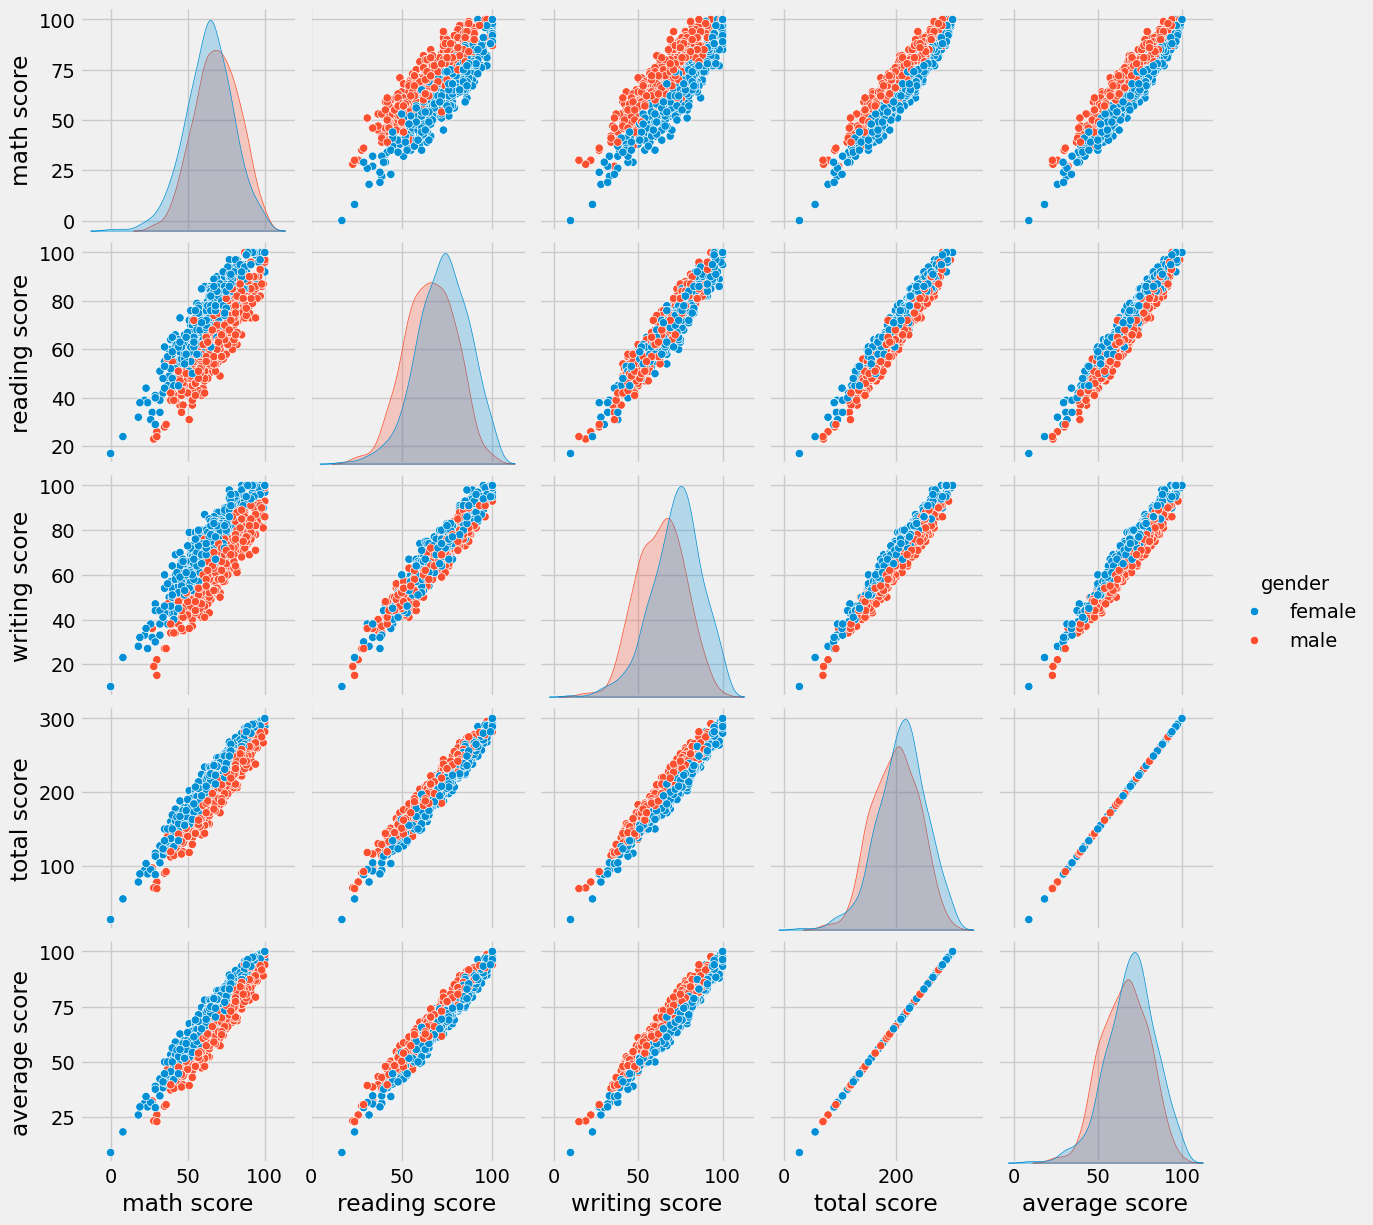

In [46]:
sns.pairplot(df,hue = 'gender')
plt.show()

**Conclusions**   
Student's Performance is related with lunch, race, parental level education   
Females lead in pass percentage and also are top-scorers   
Student's Performance is not much related with test preparation course   
Finishing preparation course is benefitial.   

In [57]:
df.to_csv('updated_data.csv', index=False)